# 🌎 Understanding the Use of the Transit Method with ML Integrations for Detecting Exoplanets 🌎

### In this project, I will be using data of flux values by time for stars, provided from the Kepler Telescope, to be able to classify a star with exoplanet(s) vs a star without exoplanet(s). To be able to classify such stars, I will use the KNN algorithm in order to accurately predict stars with exoplanets by its relationship and appearance with the rest of the given data.

In [1]:
!pip install imblearn
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 63.2 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.


In [2]:
train_df = pd.read_csv('/kaggle/input/kepler-labelled-time-series-data/exoTrain.csv')
train_df.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


In [3]:
#shape of training df
train_df.shape
#5097 stars, 3197 flux values for each star; flux values are used to plot the ligh curves to detect if a star has exoplanets orbiting it

(5087, 3198)

In [4]:
# display rows with null values
train_df[train_df.isnull().any(axis=1)]

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197


<Axes: >

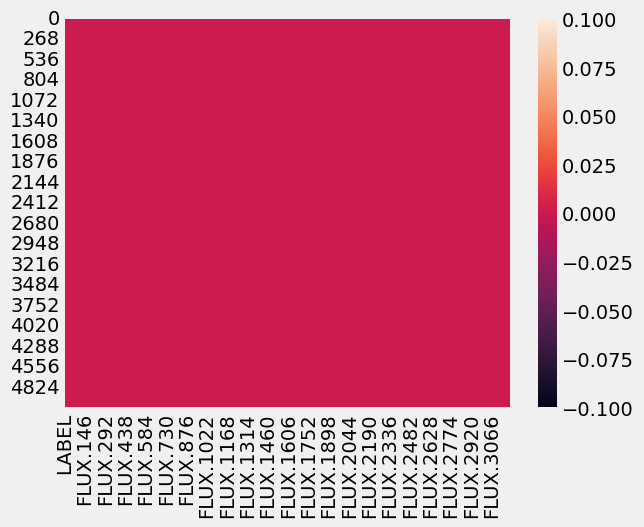

In [5]:
#display heatmap to show null values
sns.heatmap(train_df.isnull())

In [6]:
#decoding labels in dataset
train_df['LABEL'].unique()

array([2, 1])

In [7]:
#extract index for stars labeled as 2
list(train_df[train_df['LABEL'] == 2].index)

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36]

In this dataset, we can conclude that there are two classes of the data: stars with exoplanets and stars without, that being 1 and 2. Because there are so few values with the label index of 2, we can reasonably assume that these "2" stars are those with exoplanets.

[Text(0, 0, '5050'), Text(0, 0, '37')]

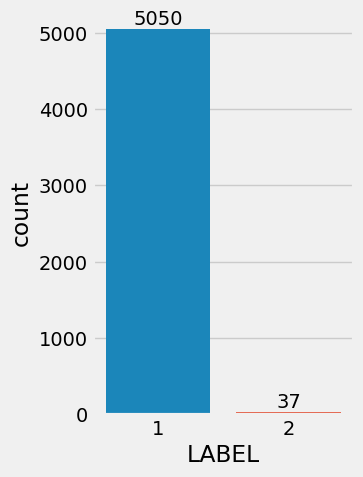

In [8]:
plt.figure(figsize=(3, 5))
ax = sns.countplot(x='LABEL', data=train_df)
ax.bar_label(ax.containers[0])

In [9]:
#replacing labels with 1 for stars with exoplanets and 2 for stars without
train_df = train_df.replace({"LABEL": {2: 1, 1: 0}})
train_df['LABEL'].unique()

array([1, 0])

## Visualizing light curves of a star with exoplanet(s) vs without

In [10]:
plot_df = train_df.drop(['LABEL'], axis = 1)

plot_df

,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,FLUX.10,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,-160.17,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,-73.38,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,484.39,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,323.33,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,-970.88,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5082,-91.91,-92.97,-78.76,-97.33,-68.00,-68.24,-75.48,-49.25,-30.92,-11.88,...,139.95,147.26,156.95,155.64,156.36,151.75,-24.45,-17.00,3.23,19.28
5083,989.75,891.01,908.53,851.83,755.11,615.78,595.77,458.87,492.84,384.34,...,-26.50,-4.84,-76.30,-37.84,-153.83,-136.16,38.03,100.28,-45.64,35.58
5084,273.39,278.00,261.73,236.99,280.73,264.90,252.92,254.88,237.60,238.51,...,-26.82,-53.89,-48.71,30.99,15.96,-3.47,65.73,88.42,79.07,79.43
5085,3.82,2.09,-3.29,-2.88,1.66,-0.75,3.85,-0.03,3.28,6.29,...,10.86,-3.23,-5.10,-4.61,-9.82,-1.50,-4.65,-14.55,-6.41,-2.55


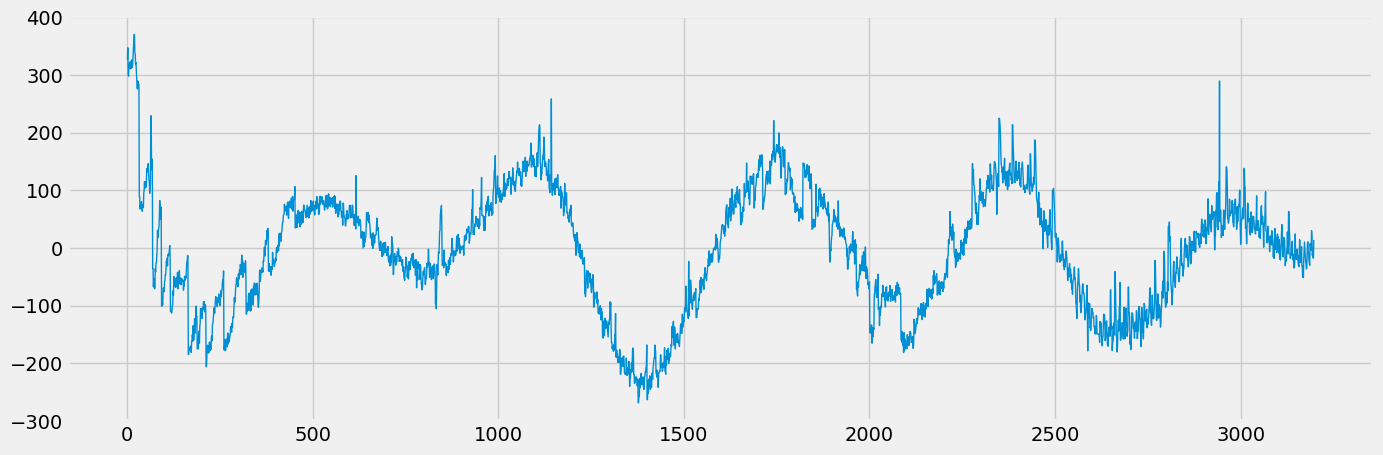

In [11]:
#plotting a star with exoplanet(s)
time = range(1, 3198)
flux_val = plot_df.iloc[3, :].values
plt.figure(figsize = (15, 5))
plt.plot(time, flux_val, linewidth = 1)

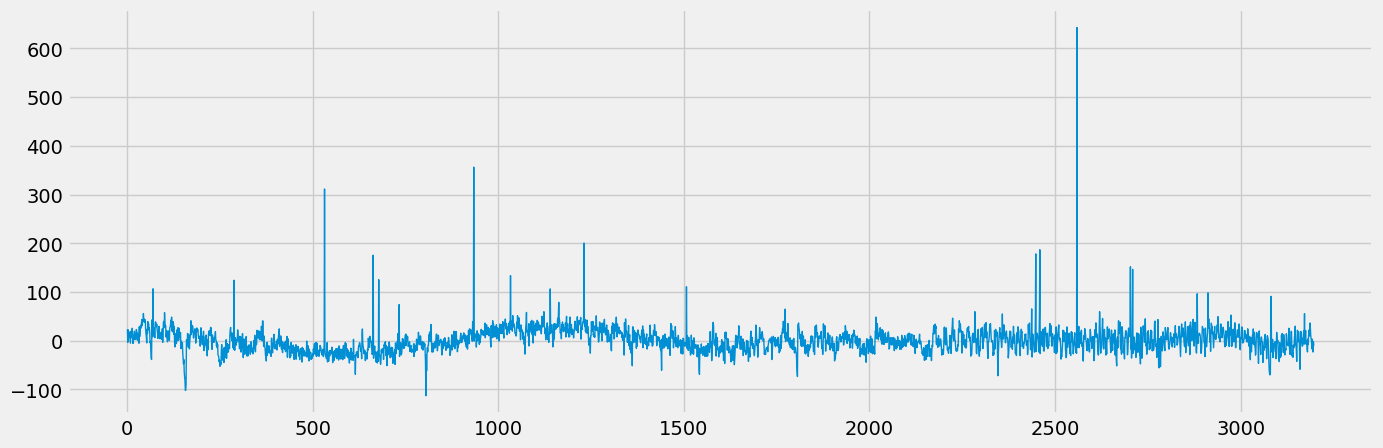

In [12]:
#plotting a star without an exoplanet
time = range(1, 3198)
flux_val = plot_df.iloc[98, :].values
plt.figure(figsize = (15, 5))
plt.plot(time, flux_val, linewidth = 1)

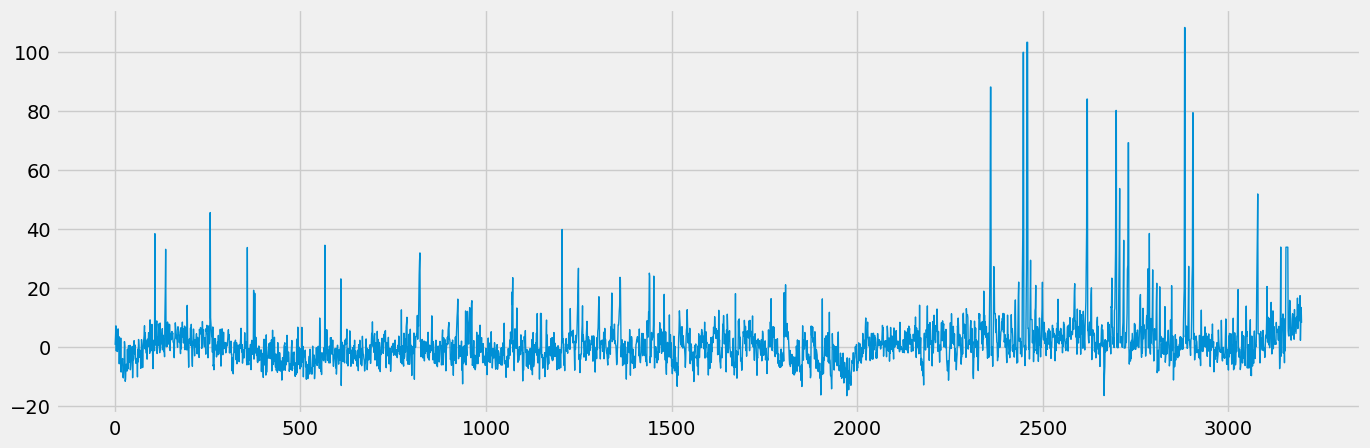

In [13]:
#plotting a star without an exoplanet
time = range(1, 3198)
flux_val = plot_df.iloc[2000, :].values
plt.figure(figsize = (15, 5))
plt.plot(time, flux_val, linewidth = 1)

As expected, we can see that stars with exoplanets have light curves that fluctuate, whereas for stars that do not, the curve seems relatively straight and stable. However, after examining multiple iterations of plots for stars without exoplanets, I am noticing some common outlier values which may affect the prediction power. It is imperative that these outliers should be removed/handled to clean the data.

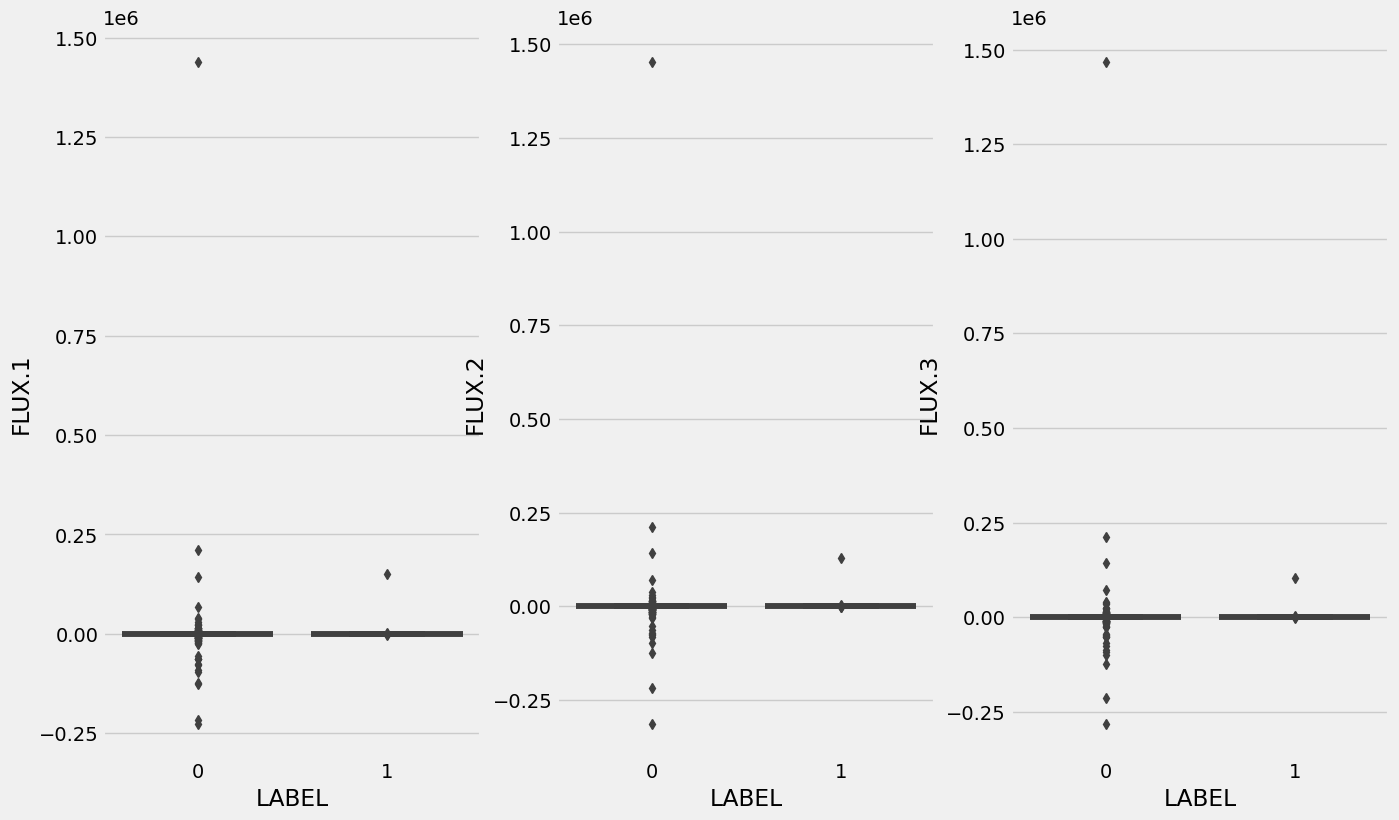

In [14]:
# locating outliers for stars without exoplanets
plt.figure(figsize=(20,9))
for i in range(1, 4):
    plt.subplot(1, 4, i)
    sns.boxplot(x = 'LABEL', y = f'FLUX.{i}',data = train_df)

In [15]:
#dropping outliers
train_df.drop(train_df[train_df['FLUX.2'] > 025e6].index, axis = 0, inplace = True)

<Axes: xlabel='LABEL', ylabel='FLUX.388'>

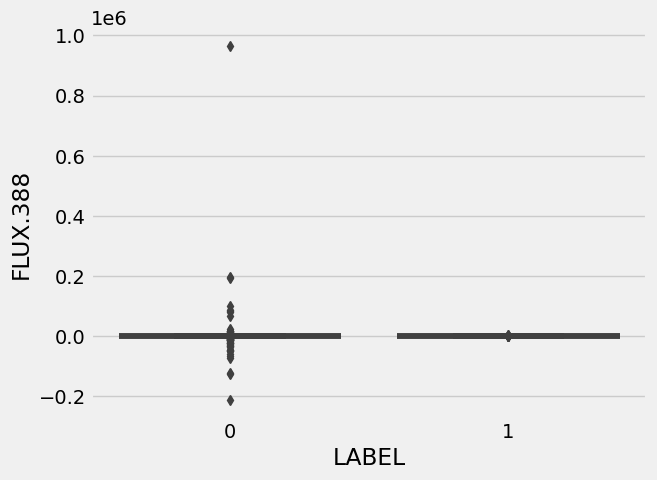

In [16]:
sns.boxplot(data = train_df, x = 'LABEL', y = f'FLUX.{np.random.randint(1000)}')

In [17]:
#extracting x and y features from training set
x = train_df.drop(['LABEL'], axis = 1)
y = train_df['LABEL']

In [18]:
#handling imbalanced data
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler()
x_ros, y_ros = ros.fit_resample(x, y)

<Axes: title={'center': 'ros applied'}, xlabel='LABEL'>

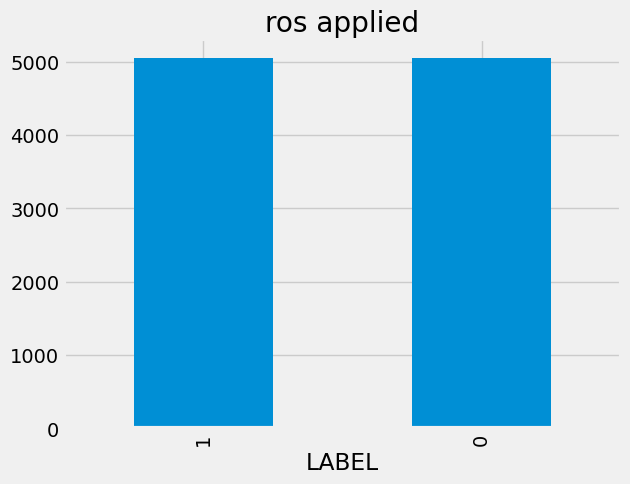

In [19]:
y_ros.value_counts().plot(kind="bar", title="ros applied")

In [20]:
from collections import Counter
print(f"Before ROS: {Counter(y)}\nAfter ROS: {Counter(y_ros)}")

Before ROS: Counter({0: 5050, 1: 37})
After ROS: Counter({1: 5050, 0: 5050})


In [21]:
#splitting training data and testing data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x_ros, y_ros, test_size = 0.3, random_state=0)

In [22]:
# feature scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [23]:
np.min(X_test_scaled), np.max(X_test_scaled)

(-35.478678016643656, 56.815925260044615)

Text(0.5, 0, 'K values')

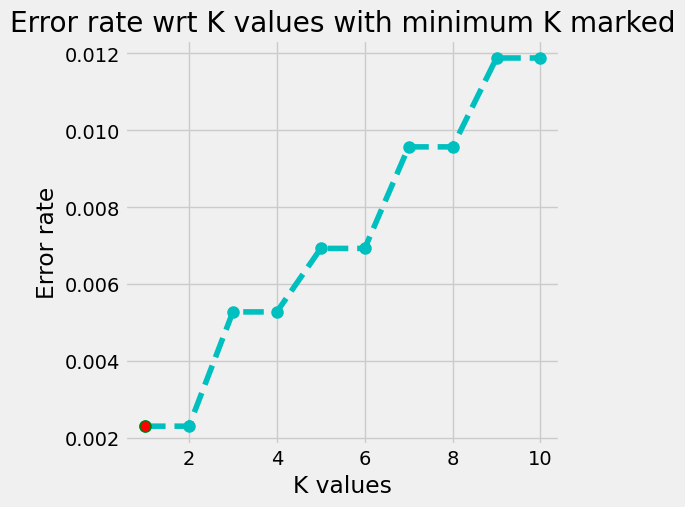

In [25]:
# choosing the best value of K for KNN
from sklearn.neighbors import KNeighborsClassifier as KNC

err_rate = []

for K in range(1, 11):
    knn_clsf = KNC(n_neighbors = K)
    knn_clsf.fit(X_train_scaled, y_train)
    pred = knn_clsf.predict(X_test_scaled)
    err_rate.append(np.mean(pred != y_test))

arg, val = err_rate.index(min(err_rate)), min(err_rate)

plt.figure(figsize = (5,5))
plt.plot(range(1,11), err_rate, 'co--', markersize = 8)
plt.plot(arg+1, val, marker='o', markersize = 8, markerfacecolor='r', markeredgecolor='g')
plt.title('Error rate wrt K values with minimum K marked')
plt.ylabel('Error rate')
plt.xlabel('K values')

In [26]:
# fitting the knn classifier model on the train data
# k = 5
knn_classifier = KNC(n_neighbors = 1, metric = 'minkowski', p = 2)

knn_classifier.fit(X_train_scaled, y_train)

#Predict
y_pred = knn_classifier.predict(X_test_scaled)

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print("Validation accuracy of KNN: ", accuracy_score(y_test, y_pred))
print()
print("Classification report: \n", classification_report(y_test, y_pred))

Validation accuracy of KNN:  0.9976897689768977

Classification report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1506
           1       1.00      1.00      1.00      1524

    accuracy                           1.00      3030
   macro avg       1.00      1.00      1.00      3030
weighted avg       1.00      1.00      1.00      3030

